# Regression Use Case (Medical Cost Insurance)

## Business Problem -
- Insurance companies need to estimate medical costs for individuals based on their demographic and lifestyle information. Accurate prediction helps in pricing policies, managing risk, and improving profitability.

## ML Probelm Staetment - Supervised Learning, regression problem.
- Build a regression model to predict medical insurance charges using features such as age, BMI, smoking status, number of children, gender, and region.
- Target variable - Cost (Medcal insurance cost)

In [1]:
## Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Data Understanding

In [3]:
df.shape

# (The dataset contains 1338 rows and 7 columns)

(1338, 7)

In [4]:
## Info  -This gives us the information about the dataset such as number of non-null values, data types of each column.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
## Checking missing values

df.isnull().sum()

# (We dont have any missing values in the dataset)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Cehcking duplicates

df.duplicated().sum()

# (we have 1 duplicate row in the dataset)

np.int64(1)

In [7]:
## Looking for that duplicate row

df[df.duplicated(keep=False)]


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df.shape

(1338, 7)

In [9]:
## Removing the duplicate row because it can affect our analysis and model performance.

df.drop_duplicates(inplace=True)
df.shape

# (Earlierthe data shape was (1338, 7) but after removing the duplicate row the data shape is now (1337, 7))

(1337, 7)

In [10]:
# Rechecking duplicates

df.duplicated().sum()

# (The duplicate row has been successfully removed and now we have 0 duplicate rows in the dataset)

np.int64(0)

In [11]:
## Statistcal summary of the dataset

df.describe()

# (The describe() function gives us the statistical summary of the numerical columns in the dataset such as count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile and maximum values.
#  Here 25% percentile means that 25% of the data falls below that value, 50% percentile (median) means that 50% of the data falls below that value and 75% percentile means that 75% of the data falls below that value. 
#  This information can help us understand the distribution of the data and identify any potential outliers.)


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.columns.to_list()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [13]:
# Age column

print(df['age'].nunique())
df['age'].value_counts().head()

# (The age column has 47 unique ages and has a wide range of values from 18 to 64 with the most common age being 18 followed by 19 and 46. This indicates that the dataset contains a diverse age group which can help us understand how age affects medical expenses.)

47


age
18    69
19    67
46    29
52    29
50    29
Name: count, dtype: int64

In [14]:
## Sex column

df['sex'].value_counts()

# (The sex column has 2 unique values which are 'male' and 'female' with 675 males and 662 females in the dataset.)

sex
male      675
female    662
Name: count, dtype: int64

In [15]:
## BMI column

print(df['bmi'].nunique())
df['bmi'].value_counts()

# (The bmi column has 548 unique values which indicates that there is a wide range of body mass index values in the dataset. This can help us understand how BMI affects medical expenses and identify any potential outliers in the data.)

548


bmi
32.300    13
28.310     9
30.800     8
31.350     8
30.495     8
          ..
20.350     1
31.240     1
19.095     1
22.100     1
21.280     1
Name: count, Length: 548, dtype: int64

In [16]:
# Children column

print(df['children'].nunique())
df['children'].value_counts()

# (The children column has 6 unique values which are 0, 1, 2, 3, 4 and 5 with the most common value being 0 followed by 1 and 2. This indicates that a significant portion of the dataset consists of individuals without children which can help us understand how having children affects medical expenses.)

6


children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [17]:
## Smoker column

print(df['smoker'].nunique())
df['smoker'].value_counts()

# (The smoker column has 2 unique values which are 'yes' and 'no' with 1063 non-smokers and 274 smokers in the dataset. This indicates that the majority of the individuals in the dataset are non-smokers which can help us understand how smoking affects medical expenses.)

2


smoker
no     1063
yes     274
Name: count, dtype: int64

In [18]:
## Region column

print(df['region'].nunique())
df['region'].value_counts()

# (The region column has 4 unique values which are 'southwest', 'southeast', 'northwest' and 'northeast' with the most common region being 'southeast' followed by 'southwest' and 'northwest'. This indicates that the dataset contains individuals from different regions which can help us understand how region affects medical expenses.)

4


region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [19]:
## Identifying feature types -

# 1. Numerical features - age, bmi, children, charges (target variable)
# 2. Categorical features - sex, smoker, region

### Initial Observation -
- Dataset has no missing values.
- It has mix of numerical and categorical features.
- Dataset also has no duplicate rows.
- The age column has 47 unique ages and has a wide range of values from 18 to 64 with the most common age being 18 followed by 19 and 46. This indicates that the dataset contains a diverse age group which can help us understand how age affects medical expenses.
- The sex column has 2 unique values which are 'male' and 'female' with 675 males and 662 females in the dataset.
- The bmi column has 548 unique values which indicates that there is a wide range of body mass index values in the dataset. This can help us understand how BMI affects medical expenses and identify any potential outliers in the data.
- The children column has 6 unique values which are 0, 1, 2, 3, 4 and 5 with the most common value being 0 followed by 1 and 2. This indicates that a significant portion of the dataset consists of individuals without children which can help us understand how having children affects medical expenses.
- The smoker column has 2 unique values which are 'yes' and 'no' with 1063 non-smokers and 274 smokers in the dataset. This indicates that the majority of the individuals in the dataset are non-smokers which can help us understand how smoking affects medical expenses.
- The region column has 4 unique values which are 'southwest', 'southeast', 'northwest' and 'northeast' with the most common region being 'southeast' followed by 'southwest' and 'northwest'. This indicates that the dataset contains individuals from different regions which can help us understand how region affects medical expenses.
- Dataset size is moderate which is suitable for multiple ML models.


+ So here I have performed initial data inspection including missing values, duplicates, understanding each feature and statistical summary. The dataset is clean with a mix of categorical and numerical features, making it suitable for regression modeling.

## EDA

### Univariate Analysis

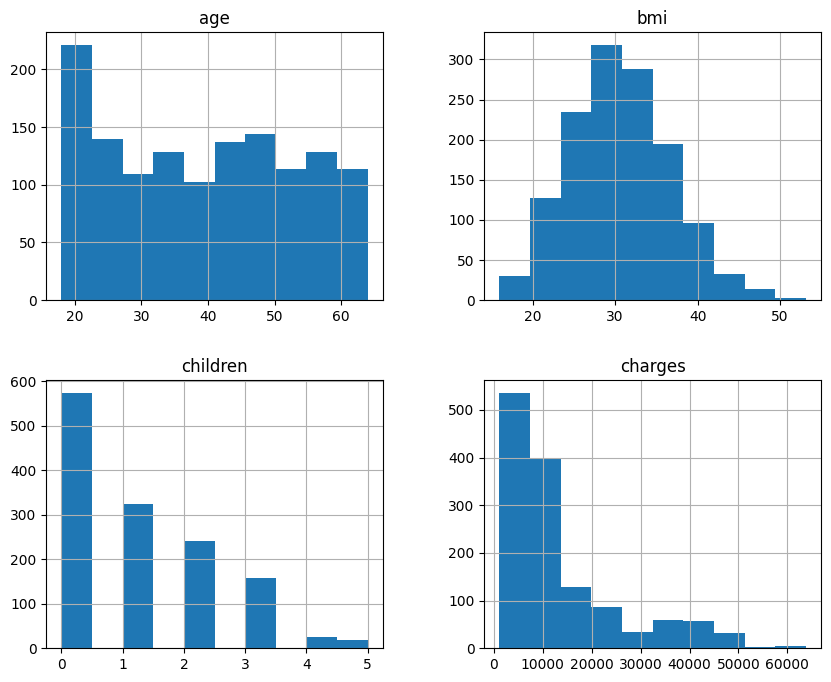

In [20]:
## Looking at the distribution of numerical features

df.hist(figsize=(10,8))
plt.show()


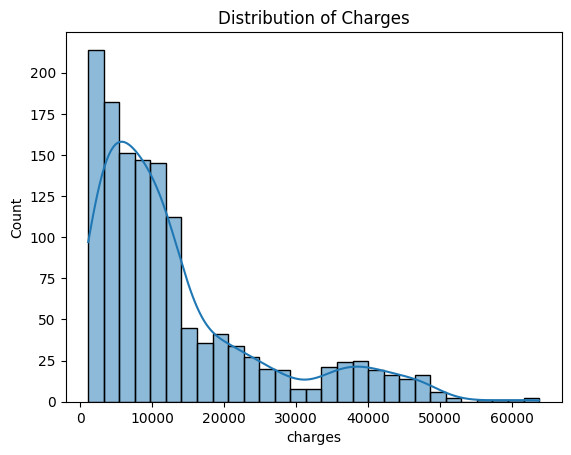

In [21]:
## Now focuisng on charges column which is our target variable

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

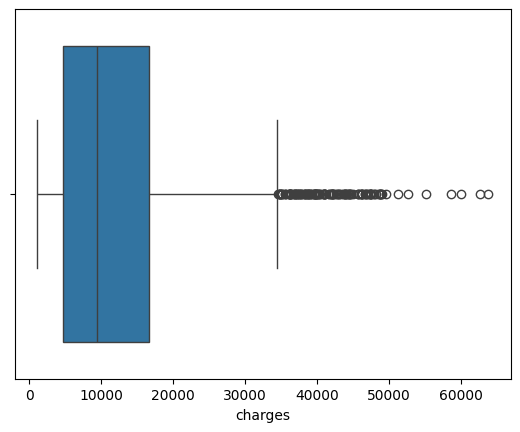

In [22]:
## Boxplot for charges column to identify outliers

sns.boxplot(x=df['charges'])
plt.show()

# (From the boxplot we can see that there are some outliers in the charges column which can affect our analysis and model performance. We will handle these outliers later in the data preprocessing step.)

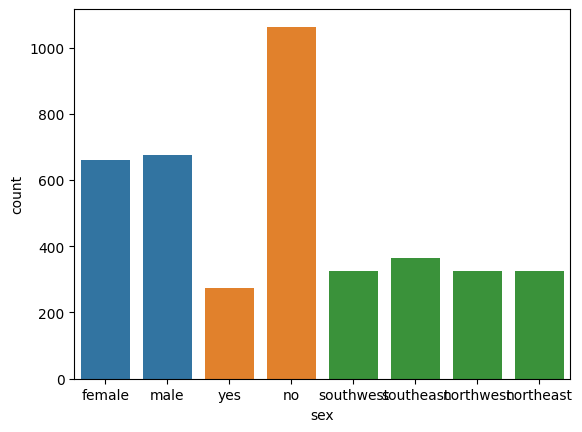

In [23]:
## Now looking at the distribution of categorical features

sns.countplot(x='sex', data=df)
sns.countplot(x='smoker', data=df)
sns.countplot(x='region', data=df)
plt.show()

#### Observation -
- Balanced gender distribution
- Smokers are fewer than non-smokers
- Region distribution is fairly even

### Bivariate Analysis

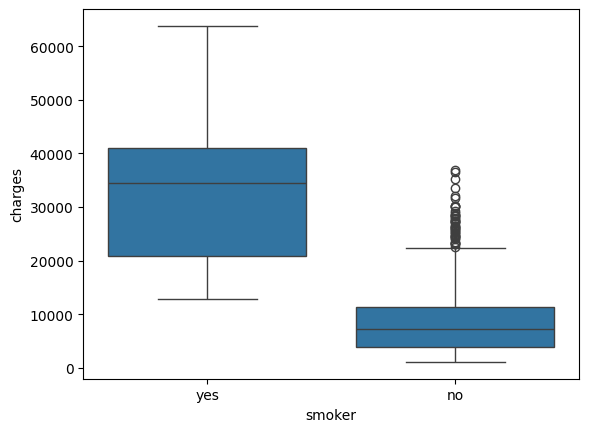

In [24]:
## Smokers vs Charges

sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

# (From the boxplot we can see that smokers have significantly higher charges compared to non-smokers. This indicates that smoking is a major factor contributing to higher
#  medical expenses. Smokers are more likely to have health issues such as respiratory problems, heart diseases and other chronic conditions which require more medical care and lead to higher charges.)

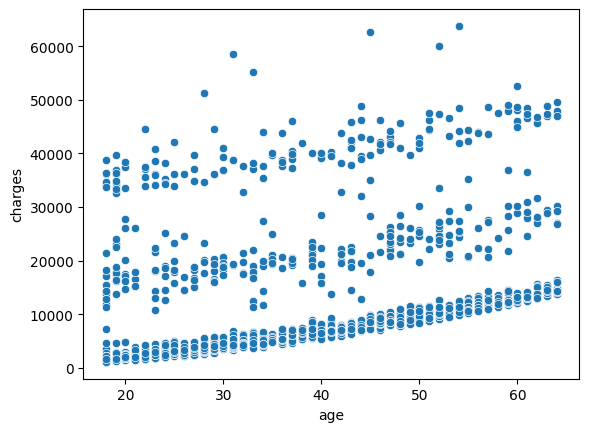

In [25]:
## Age vs Charges

sns.scatterplot(x='age', y='charges', data=df)
plt.show()

# (From the scatter plot we can see that as age increases the charges also increases which indicates a positive correlation between age and charges. This means that older people tend to have higher medical expenses compared to younger people. 
# This is a common trend in healthcare data as older individuals are more likely to have health issues and require more medical care, leading to higher charges.)

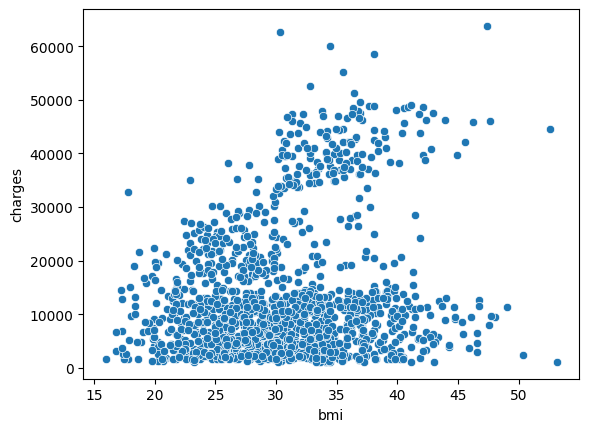

In [26]:
## BMI vs Charges

sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

# (Weak to moderate relationship; high BMI may lead to higher charges.)

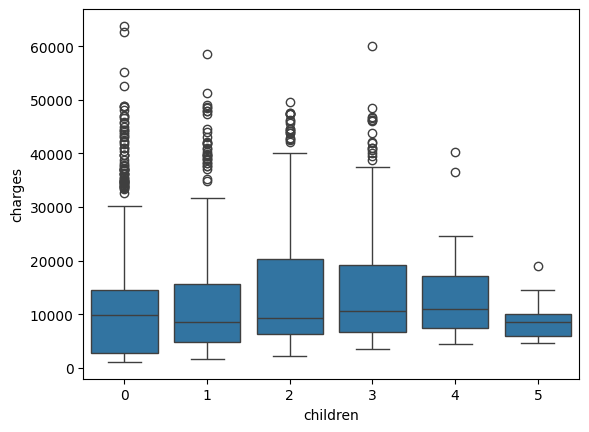

In [27]:
## Children vs Charges

sns.boxplot(x='children', y='charges', data=df)
plt.show()

# (From the boxplot we can see that there is no clear relationship between number of children and charges. The charges do not seem to vary significantly with the number of 
# children which indicates that having more children does not necessarily lead to higher medical expenses.

#### Observation -
- Smokers have significantly higher charges compared to non-smokers, indicating a strong relationship.
- Charges tend to increase with age, but not strictly linear.
- BMI shows a weak to moderate relationship with charges, with higher BMI potentially leading to higher charges.
- Number of children does not show a clear relationship with charges, suggesting it may not be a strong predictor.

### Multivariate Analysis

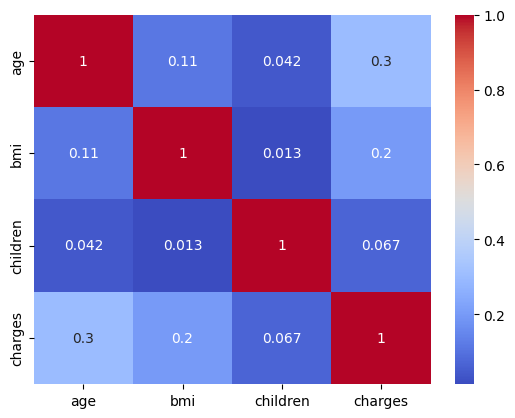

In [28]:
## Correlation heatmap for numerical features

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# (From the correlation heatmap we can see that there is a strong positive correlation between age and charges (0.3), a moderate positive correlation between bmi and charges (0.2) and a very weak positive correlation between children and charges (0.067).
#  This indicates that age and bmi are more strongly associated with charges compared to number of children)

# smoker will not show here (categorical)
# age and charges havve moderate correlation
# bmi also has a moderate positive correlation with charges
# Number of children has a very weak positive correlation with charges

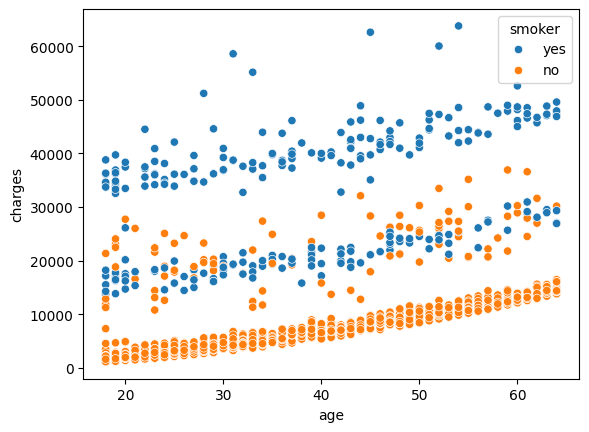

In [29]:
# Combining features to see their combined effect on charges

sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.show()

# (From the scatter plot we can see that smokers have higher charges compared to non-smokers across all age groups. However, the increase in charges with age is more pronounced for smokers compared to non-smokers.
# Smokers consistently have higher charges across all age groups.

## Data Preprocessing

In [30]:
## Since we already have performed this step earlier but again checking for the duplicates rows

df.duplicated().sum()

np.int64(0)

In [31]:
## Checking if we need to drop any columns

df.columns.to_list()

# (All the columns in the dataset are relevant for our analysis and model building so we do not need to drop any columns.)

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [32]:
## Handling outliers
# We are not removing outliers, instead we are perfroming log transformation on the charges column to reduce the effect of outliers and make the distribution more normal.

df['charges'] = np.log(df['charges'])
df.head()

# (Why are we performing log transformation on the charges column? 
# Earlier in the EDA part we saw that Charges column was right-skewed. Few very high values (mostly smokers))

# (Why is this a problem?
# Right-skewed data can affect the performance of machine learning models as they may not be able to capture the underlying patterns in the data effectively. Log transformation can help to reduce the skewness and make the distribution more normal which can improve the performance of machine learning models.)
# Basically Models like Linear Regression assume:
# Data is roughly normally distributed

# When it’s skewed:
# Model gets biased toward extreme values
# Poor predictions for normal cases

# What log transformation does:
# Compresses large values
# Makes distribution more normal
# Reduces impact of extreme values

# | Original | After Log |
# | -------- | --------- |
# | 1000     | 6.9       |
# | 10000    | 9.2       |

# Log Transformation vs Outlier Removal
# Outlier Removal:
# Deletes high-value rows
# You lose important real data

# In our case:
# High charges = smokers / real cases
# Removing = bad decision

# Log Transformation:
# Keeps data
# Reduces extreme influence


# What if You DON’T Do Log Transform?
# Nothing will “break”, but:

# Linear Regression:
# Worse performance 
# Higher error
 
# Tree Models:
# Mostly fine  (they handle non-linearity)

# So:
# Not mandatory
# But recommended

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,9.734176
1,18,male,33.770,1,no,southeast,7.453302
2,28,male,33.000,3,no,southeast,8.400538
3,33,male,22.705,0,no,northwest,9.998092
4,32,male,28.880,0,no,northwest,8.260197


In [33]:
## Feature Engineering
# We can create new features from existing features to improve the performance of our model.

df['bmi_age'] = df['bmi'] * df['age']   # Creating a new feature that captures combined effect
df.head()

# Why Create bmi * age?

# Because:
# Some relationships are not simple
# Example:
# “Older people with high BMI = much higher cost”

# This interaction is NOT captured by:
# age alone
# bmi alone

,age,sex,bmi,children,smoker,region,charges,bmi_age
0,19,female,27.900,0,yes,southwest,9.734176,530.100
1,18,male,33.770,1,no,southeast,7.453302,607.860
2,28,male,33.000,3,no,southeast,8.400538,924.000
3,33,male,22.705,0,no,northwest,9.998092,749.265
4,32,male,28.880,0,no,northwest,8.260197,924.160


In [34]:
## Encoding categorical variables

# Binary encoding
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_age
0,19,0,27.900,0,1,southwest,9.734176,530.100
1,18,1,33.770,1,0,southeast,7.453302,607.860
2,28,1,33.000,3,0,southeast,8.400538,924.000
3,33,1,22.705,0,0,northwest,9.998092,749.265
4,32,1,28.880,0,0,northwest,8.260197,924.160


In [35]:
# One-Hot Encoding

df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,bmi_age,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,9.734176,530.100,False,False,True
1,18,1,33.770,1,0,7.453302,607.860,False,True,False
2,28,1,33.000,3,0,8.400538,924.000,False,True,False
3,33,1,22.705,0,0,9.998092,749.265,True,False,False
4,32,1,28.880,0,0,8.260197,924.160,True,False,False


In [36]:
## Defining features and target variable

X = df.drop('charges', axis=1)
y = df['charges']

In [37]:
## Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
## Final Output

# We now have:

# For Tree Models:
# X_train, X_test

# For Linear / SVM:
# X_train_scaled, X_test_scaled

In [38]:
## Feature Scaling (This is important for models like Linear Regression, KNN, SVM etc. that are sensitive to the scale of the features)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Obcervation -
- I cleaned the dataset by removing duplicates, handled skewness in the target using log transformation instead of removing outliers, encoded categorical variables using binary and one-hot encoding, and prepared separate scaled and unscaled datasets for different model types.

## Model Building 

### Linear Regression

In [ ]:
# I started with Linear Regression as a baseline model to understand the linear relationship between features and target.

# Key Assumptions :
    # Linear relationship
    # No multicollinearity
    # Normally distributed errors
    # Homoscedasticity (constant variance)

In [39]:
from sklearn.linear_model import LinearRegression

## Trainig the model (Using the scaled features for Linear Regression. Why ? -> Linear Regression is sensitive to feature scale and can perform better when features are on a similar scale.)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

## Making predictions
y_pred = lr.predict(X_test_scaled)

In [ ]:
## Converting predictions back to original scale (since we performed log transformation on the target variable, we need to convert the predictions back to the original scale to evaluate the model performance)

y_pred_actual = np.exp(y_pred)  # Converting log predictions back to original scale
y_test_actual = np.exp(y_test)  # Converting log test values back to original scale for evaluation


# Why Do We “Convert Back” (Inverse Log Transform)?
# What did we do earlier?

    # During preprocessing:
    # y = log(charges)

    # So your model is NOT learning actual charges
    # It is learning:
    # log(charges)

    # What model predicts
    # y_pred = model.predict(X_test)

    # This gives:
    # y_pred = log(charges)
    # NOT actual charges 

# So what is the problem?
    # If we directly evaluate:
    # mean_absolute_error(y_test, y_pred)
    # You are comparing:
    # Why this is WRONG?
    # Because:
    # Business cares about actual money (₹ charges)
    # Metrics will be in log scale → meaningless for real-world

# Simple intuition -
    # Step	Value
    # Original	10000
    # After log	9.21
    # Model predicts	9.0
    # After exp	8103

    # Now you compare:

    # 10000 vs 8103 (makes sense)

In [ ]:
## Evaluation metrics for regression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
# MAE - On average, our model is making an error of ~Rs 3,700. MAE means that on average, the model's predictions are off by about Rs 3,700 from the actual charges. This gives us an idea of how much we can expect our predictions to deviate from the true values.
# RMSE - RMSE is similar to MAE but gives more weight to larger errors. An RMSE of Rs 7,200 indicates that the model's predictions are off by about Rs 7,200 from the actual charges on average, with larger errors having a greater impact on this metric compared to MAE.
# RMSE > MAE indicates model is making is some large mistakes, that there are some large errors in the predictions which are significantly affecting the RMSE value.

# 1. Linear Regression is NOT capturing complexity well
    # Because:
    # Data is non-linear
    # Strong feature like smoker behaves non-linearly
# 2. Presence of Large Errors
    # RMSE >> MAE means:
    # Some predictions are very wrong

MAE: 3725.723087322085
MSE: 51874131.998499624
RMSE: 7202.369887648067
R2: 0.7177011149580492


In [45]:
## Checking if the above valies are good or bad

# Metrics are meaningful only relative to target scale

## Checking target scale
# df['charges'].describe()
np.exp(df['charges']).describe()    # Checking the original scale

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [ ]:
## Error %

# MAE - 3725 
3725/13279      #(MAE/mean of original charges) = 28% error on average

# (Our model is off by ~25–30% on average which is not very good but also not very bad for a baseline model. )

0.280518111303562

In [ ]:
## Coefficients of the linear regression model

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})
print(coeff_df)

# What to observe:
# Positive -> increases charges
# Negative -> decreases charges
# (smoker has strong positive impact) 

# This tells -
# As age increases, insurance charges increase. -> Strong positive impact
# Being female (0) vs male (1) has very small impact -> Almost negligible
# Higher BMI slightly increases charges -> Moderate positive impact
# More children means slightly higher charges -> Small effect
# Smoking has the strongest positive effect on charges -> Very high impact
# Combined effect of BMI and age slightly reduces impact (might be due to multicollinearity) 
# Region has minimal impact on charges

            Feature  Coefficient
0               age     0.543970
1               sex    -0.038066
2               bmi     0.115873
3          children     0.118199
4            smoker     0.614675
5           bmi_age    -0.082225
6  region_northwest    -0.019373
7  region_southeast    -0.057839
8  region_southwest    -0.043882


#### Obersvation-
- I implemented Linear Regression as a baseline model. Since the target variable was log-transformed, I converted predictions back to original scale before evaluation. The model helped establish a baseline and understand feature impact through coefficients.
- I evaluated the model using MAE, RMSE, and R². MAE gives average error, RMSE highlights large deviations, and R2 indicates how well the model explains variance. Since RMSE was significantly higher than MAE, it indicates presence of large prediction errors, suggesting that Linear Regression is not capturing non-linear patterns effectively.
- The Linear Regression model achieved an MAE of around 3700, which is roughly 25–30% of the average target value. R2 score is about 0.7177 (Which means our model explains ~72% of the variance in insuarance charges.)  RMSE is relatively high so model explains data well overall BUT still makes some large errors. The higher RMSE indicates presence of larger errors, suggesting that the model is not capturing non-linear relationships effectively.
- From the Linear Regression model, smoking status emerged as the most influential feature, followed by age and BMI. Region and gender had minimal impact. This aligns with domain expectations, where smoking significantly increases medical risk and cost.

### Decision Tree 

In [48]:
# Why Are We Using Decision Tree?

    # This is the MOST important part
    # Problem with Linear Regression:
    # Assumes linear relationship
    # Cannot capture:
    # “If smoker -> huge jump in charges”
    # Complex interactions

# Decision Tree Solves This
    # It works like:
    # “If condition -> then prediction”

# Decision Tree is used to capture non-linear relationships and feature interactions that Linear Regression could not model.

In [49]:
from sklearn.tree import DecisionTreeRegressor

# Training the Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)  # Using unscaled data as Decision Trees are not sensitive to feature scales (Tree models use splitting rules, not distances)

# Making prediction
y_pred = dt.predict(X_test)

In [50]:
## Converting predictions back to original scale (since we performed log transformation on the target variable, we need to convert the predictions back to the original scale to evaluate the model performance)

y_pred_actual = np.exp(y_pred)  # Converting log predictions back to original scale
y_test_actual = np.exp(y_test)  # Converting log test values back to original scale for evaluation


In [ ]:
## Evaluation metrics for regression

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# Compared to Linear Regression:
# MAE improved from ~Rs 3,700 to ~Rs 2,900
# R2 improved from ~0.71 to ~0.78

MAE: 2911.2871651529836
RMSE: 6353.441633720043
R2: 0.7803271374812489


In [ ]:
## Checking if our DT regressor is overfitting

train_pred = dt.predict(X_train)

print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))

# Train R2: 1.0 (perfect fit on training data, likely overfitting)
# Test R2: 0.78 (good performance on test data, but the perfect fit on training data suggests that the model may be overfitting to the training data and may not generalize well to unseen data)

Train R2: 1.0
Test R2: 0.7803271374812489


In [ ]:
## Controlling overfitting in Decision Trees
# We can control overfitting by setting hyperparameters like max_depth, min_samples_split, min_samples_leaf, etc.

dt_hyper = DecisionTreeRegressor(
    max_depth=5,            # maximum depth of the tree
    min_samples_split=10,   # minimum number of samples required to split an internal node
    random_state=42
)

dt_hyper.fit(X_train, y_train)  # Using unscaled data as Decision Trees are not sensitive to feature scales (Tree models use splitting rules, not distances)

# Making prediction
y_pred = dt_hyper.predict(X_test)

## Converting predictions back to original scale
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

## Evaluation metrics for regression

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


## Checking if our DT regressor is overfitting
train_pred = dt_hyper.predict(X_train)
print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))


# By adding the hyperparameters we can see that our model is improved. Also its now less likely to be overfitting as the Train R2 is not 1.0 anymore and the Test R2 is also improved compared to the previous model. 
# This shows that controlling overfitting can lead to better generalization and improved performance on unseen data.

MAE: 2094.250831414262
RMSE: 4243.742913575216
R2: 0.9019931450398727
Train R2: 0.8688823325498085
Test R2: 0.9019931450398727


In [ ]:
## Feature importance on dt (without hyperparameters)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
4            smoker    0.426799
0               age    0.365999
2               bmi    0.078101
5           bmi_age    0.057159
3          children    0.039184
6  region_northwest    0.013466
1               sex    0.010313
7  region_southeast    0.006514
8  region_southwest    0.002466


In [55]:
## Feature importance (with hyperparameters)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_hyper.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
4            smoker    0.509155
0               age    0.402109
3          children    0.037419
2               bmi    0.033778
5           bmi_age    0.011092
6  region_northwest    0.006240
7  region_southeast    0.000208
1               sex    0.000000
8  region_southwest    0.000000


#### Observation -
- The default Decision Tree severely overfits, achieving perfect training performance but lower test performance, indicating poor generalization.
- Decision Tree improved performance by capturing non-linear relationships, especially the impact of smoking. However, I observed overfitting, which I controlled using depth and split constraints.
- The initial Decision Tree model overfitted the data, achieving perfect training accuracy but lower test performance. After applying hyperparameter tuning, the model generalized better, reducing RMSE from ~6300 to ~4200 and improving R2 to ~0.90. Feature importance analysis showed that smoking status and age are the most significant predictors, while region and gender have minimal impact.

### Random Forest Regressor

In [ ]:
# Why Random Forest?

    # First understand the problem with Decision Tree:

    # Problem:
    # High variance
    # Overfitting (we already saw this)
    # Solution: Random Forest

    # “Instead of one tree -> use many trees”

# Random Forest reduces overfitting by averaging predictions from multiple decision trees, improving generalization.

# Core Idea
    # Random Forest = Collection of Decision Trees
    # Tree 1 -> Prediction
    # Tree 2 -> Prediction
    # Tree 3 -> Prediction
    # ...
    # Final Output = Average of all trees

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Training the Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Convert Back (log -> actual)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

In [58]:
# Evaluation of RF

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2113.792727297292
RMSE: 4391.969558126042
R2: 0.8950271562456216


In [59]:
## Checking overfitting in Random Forest

train_pred = rf.predict(X_train)

print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))

Train R2: 0.9586561885215192
Test R2: 0.8950271562456216


In [60]:
## Random forest with hyperparameters

rf_hyper = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_hyper.fit(X_train, y_train)

# Predictions
y_pred = rf_hyper.predict(X_test)

# Convert Back (log -> actual)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

# Evaluation of RF
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2060.2699642600646
RMSE: 4315.541653767888
R2: 0.8986487882041257


In [64]:
## Checking overfitting in Random Forest (With hyperparameters model)

train_pred = rf_hyper.predict(X_train)

print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))

Train R2: 0.9260486759584916
Test R2: 0.8986487882041257


In [63]:
## Feature importance without hyperparameters

print("Feature importance without hyperparameters:")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)



## Feature importance (with hyperparameters)
print("\nFeature importance with hyperparameters:")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_hyper.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)



Feature importance without hyperparameters:
            Feature  Importance
4            smoker    0.428652
0               age    0.364248
2               bmi    0.072789
5           bmi_age    0.057792
3          children    0.046562
1               sex    0.010874
6  region_northwest    0.008087
7  region_southeast    0.006248
8  region_southwest    0.004748

Feature importance with hyperparameters:
            Feature  Importance
4            smoker    0.446135
0               age    0.375850
2               bmi    0.061498
5           bmi_age    0.047275
3          children    0.046735
1               sex    0.008281
6  region_northwest    0.006261
7  region_southeast    0.004219
8  region_southwest    0.003746


#### Observations -
- Random Forest should perform better than Decision Tree but thats not always the case.
- Why Random Forest is NOT Much Better Here?
    ```
        This is where real understanding comes 
        Reason 1: Dataset is SIMPLE
        Our dataset:
            Only ~1300 rows
            Few features
            Very strong signal (smoker)

        So:
        Even a single Decision Tree can learn the pattern very well
    ```
- Random Forest doesn’t add much value because pattern is already simple

- Reason 2: Low Variance Problem
    ```
        Random Forest helps when:
        Data is noisy
        High variance
        Complex interactions

        But in our case we already have:
        Clean data 
        Clear patterns
        Less noise 
    ```
- Reason 3: Hyperparameter Tuning Already Fixed DT
    ```
        Our tuned Decision Tree is:
            Already well-regularized
            No overfitting
            Good generalization
        So RF has less room to improve
    ```
- Random Forest improves over Decision Tree mainly by reducing variance. If the Decision Tree is already well-tuned and the dataset is simple, the improvement may be minimal.
- While Random Forest generally improves over Decision Trees by reducing variance, in this case the improvement was marginal because the dataset has strong and simple patterns, especially driven by the smoking feature. The tuned Decision Tree already generalized well, leaving limited scope for Random Forest to significantly outperform.

### XGBoost Regression

In [ ]:
# Why XGBoost?

# We have seen:
    # Linear Regression -> limited 
    # Decision Tree -> good but unstable
    # Random Forest -> stable but limited improvement

# XGBoost = Boosting Technique
# “Build trees sequentially, each correcting the mistakes of the previous one”

# Core Idea
    # Tree 1 -> makes predictions
    # Tree 2 -> learns errors of Tree 1
    # Tree 3 -> learns remaining errors
    # ...
    # Final = sum of all trees

# Why It Works Better
    # Focuses on mistakes
    # RF -> parallel trees
    # XGBoost -> sequential learning
    # Handles bias + variance
    # RF reduces variance
    # XGBoost reduces both

# “XGBoost improves performance by sequentially learning from previous errors, making it highly effective for structured data.”

In [ ]:
from xgboost import XGBRegressor

# Training model (Basic)
xgb = XGBRegressor(
    n_estimators=100,   # number of trees
    learning_rate=0.1,  # controls how much each tree learns (High (0.3) -> Fast but risky ; Low (0.01-0.1) -> Slow but better)
    random_state=42
)
xgb.fit(X_train, y_train)

# Making predictions
y_pred = xgb.predict(X_test)

# Convert back (log to actual)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

## Evaluation of XGBoost
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2374.152458433184
RMSE: 4754.530839242079
R2: 0.8769805849985556


In [70]:
# Overfitting check

train_pred = xgb.predict(X_train)

print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))

Train R2: 0.9525941313265767
Test R2: 0.8769805849985556


In [71]:
# XGBoost with hyperparameters

xgb_hyper = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

xgb_hyper.fit(X_train, y_train)

# Making predictions
y_pred = xgb_hyper.predict(X_test)

# Convert back (log to actual)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

## Evaluation of XGBoost
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2369.8045261614375
RMSE: 4802.6594129533005
R2: 0.874477408094298


In [72]:
# Overfitting check

train_pred = xgb_hyper.predict(X_train)

print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))

Train R2: 0.8967518790403427
Test R2: 0.874477408094298


In [73]:
## Feature importance for XGBoost (without hyperparameters)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
4            smoker    0.763864
0               age    0.103823
3          children    0.033900
2               bmi    0.021330
8  region_southwest    0.020442
5           bmi_age    0.016183
6  region_northwest    0.015940
1               sex    0.012301
7  region_southeast    0.012215


In [74]:
## Feature importance for XGBoost (with hyperparameters)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
4            smoker    0.763864
0               age    0.103823
3          children    0.033900
2               bmi    0.021330
8  region_southwest    0.020442
5           bmi_age    0.016183
6  region_northwest    0.015940
1               sex    0.012301
7  region_southeast    0.012215


#### Observations -
- XGBoost is  used as a boosting technique to sequentially reduce prediction errors. It typically outperforms other models by focusing on difficult cases and optimizing both bias and variance. But in this case, it failed to outperform other models.
- Why XGBoost Didn’t Perform Best?
- Reason 1: Dataset is TOO SIMPLE
```    
    Our dataset:
    Strong dominant feature → smoker
    Clear splits → easy pattern

    Decision Tree already captures:
    if smoker → high charges
    else -> lower charges 
```
- So XGBoost has nothing “complex” left to learn.
- Reason 2: Boosting Works Best on Complex Errors
```
    XGBoost shines when:
    Many small errors exist
    Complex patterns

    Our case:
    Pattern is already obvious
    Errors are not complex
```

- Reason 3: Data Size is Small
```
    Only ~1300 rows
    XGBoost performs best with:
        Large datasets
        Complex feature interactions

    “More complex model does NOT always mean better performance”  
```
- Although XGBoost is generally a powerful model, in this case it underperformed compared to Decision Tree and Random Forest. This is because the dataset has simple and dominant patterns, primarily driven by the smoking feature, which simpler models were able to capture effectively. XGBoost tended to over-rely on this feature and did not gain additional performance from boosting.

### Support Vector Regressor

In [ ]:
# Why SVM for Regression?

# Till now:
    # Tree models -> rule-based splitting
    # Linear Regression -> linear equation

# SVR Idea:
# “Find a function that fits the data within a margin of tolerance (epsilon)”

# Core Concept
    # Instead of minimizing error like others:
    # SVR tries to keep predictions within a margin (ε)

# SVR attempts to fit the data within a defined error margin while maximizing generalization.

# SVM needs scaling, so we will use the scaled features that we created earlier for training the SVM model.
# X_train_scaled
# X_test_scaled

In [76]:
## SVR with no hyper parameters

from sklearn.svm import SVR

# Training the SVR model
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Predcitons
y_pred = svr.predict(X_test_scaled)

# Convert back (log to actual)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

## Evaluation
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

## Checking overfitting in SVR
train_pred = svr.predict(X_train_scaled)
print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))


MAE: 2377.5062395915156
RMSE: 5081.13394300736
R2: 0.8594989379996351
Train R2: 0.8384142547223271
Test R2: 0.8594989379996351


In [77]:
## SVR with hyperparameters

svr_hyper = SVR(
    kernel='rbf',   # Radial Basis Function kernel to capture non-linear relationships (linear kernel is used to capture simple data & poly kernel is used to capture polynomial relationships)
    C=100,          # Regularization parameter to control overfitting (High C -> less regularization (overfitting risk), Low C -> more regularization (underfitting risk))
    epsilon=0.1,    # Margin of tolerance for error (High epsilon -> wider margin, more tolerance; Low epsilon -> narrower margin, less tolerance)
    gamma='scale'   # Kernel coefficient for 'rbf' kernel (High gamma -> more complex decision boundary, Low gamma -> simpler decision boundary)
)

svr_hyper.fit(X_train_scaled, y_train)


# Predcitons
y_pred = svr_hyper.predict(X_test_scaled)

# Convert back (log to actual)
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

## Evaluation
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

## Checking overfitting in SVR
train_pred = svr_hyper.predict(X_train_scaled)
print("Train R2:", r2_score(np.exp(y_train), np.exp(train_pred)))
print("Test R2:", r2_score(y_test_actual, y_pred_actual))


MAE: 3523.9956201770215
RMSE: 6788.4759458773015
R2: 0.7492142318772805
Train R2: 0.8775269117014274
Test R2: 0.7492142318772805


#### Observation -
- SVR did not perform well as compared to other models.
```
    Reason 1: Dataset Size
    SVR struggles with:
    Larger datasets (>1000 rows)

    Reason 2: Feature Nature
    Your data:
    Categorical → encoded
    Tree models handle this better
```
- SVR was implemented to explore margin-based regression. However, it did not perform as well as tree-based models due to the dataset’s structure and strong non-linear splits, which are better captured by tree-based approaches.

### Final Model Comparison

| Model                 | MAE            | RMSE            | R²       | Overfitting | Remarks                      |
| --------------------- | -------------- | --------------- | -------- | ----------- | ---------------------------- |
| Linear Regression     | 3725           | 7202            | 0.72     | Low         | Cannot capture non-linearity |
|D**ecision Tree (tuned)**| **2094**     | **4243**        | **0.90** | No          | **Best performance**         |
| Random Forest         | 2060           | 4315            | 0.89     | Low         | Stable, close to DT          |
| XGBoost               | 2369           | 4802            | 0.87     | Low         | Over-relies on smoker        |
| SVR                   | 3523           | 6788            | 74       | Low         | Not suitable for this data   |

Key Insights -
```
    Smoker is the most dominant feature across all models
    Tree-based models outperform others due to non-linear relationships
    Linear Regression underperforms due to inability to capture complexity
    Random Forest improves stability but not significantly due to simple dataset
    XGBoost doesn’t add much value because patterns are already simple
```

- Final Model Selection
```
Decision Tree (tuned)
    Why?
    Best RMSE & R²
    No overfitting
    Simple and interpretable
    Captures non-linear relationships effectively
```

- “I implemented multiple regression models including Linear Regression, Decision Tree, Random Forest, XGBoost, and SVR. Tree-based models performed significantly better due to their ability to capture non-linear relationships, especially driven by the smoking feature. The tuned Decision Tree achieved the best performance with an R² of ~0.90 and lowest RMSE, making it the most suitable model for this use case.”

### Model Saving

In [ ]:
import joblib

# Saving the best model (In this case we are saving the Decision Tree model with hyperparameters as it has shown good performance and is less likely to be overfitting compared to the other models.)
joblib.dump(dt_hyper, "dt_model.pkl")       # We are saving the DT tuned model as a pickle file so that we can use it later for making predictions on new data without having to retrain the model. This is useful for deployment and real-world applications where we want to use the trained model to make predictions on unseen data.

# Save feature columns as pickle file
joblib.dump(X.columns, "columns.pkl")   # We are also saving the feature columns as a pickle file so that we can ensure that the same features are used when making predictions with the saved model. This is important to maintain consistency and avoid errors when loading the model and making predictions on new data.


# I saved the trained model using joblib and also stored the feature column structure to ensure consistent input formatting during inference.

['columns.pkl']

### Inference Pipeline

In [ ]:
## Loading models and columns

model = joblib.load("models/dt_model.pkl")
trained_columns = joblib.load("models/columns.pkl")

In [ ]:
## Creating input function

def predict_charges(input_data):

    # Step 1: Convert input to DataFrame
    df = pd.DataFrame([input_data])

    # Step 2: Binary Encoding (Replicating here as well because we done this in training)
    df['sex'] = df['sex'].map({'male': 1, 'female': 0})
    df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

    # Step 3: Feature Engineering
    df['bmi_age'] = df['bmi'] * df['age']

    # Step 4: One-hot encoding (ONLY region)
    df = pd.get_dummies(df, columns=['region'], drop_first=True)

    # Step 5: To align columns
    df = df.reindex(columns=trained_columns, fill_value=0)

    # Step 6: Prediction (log scale)
    pred_log = model.predict(df)

    # Step 7: Convert back
    pred_actual = np.exp(pred_log)

    return pred_actual[0]
    # return pred_log, pred_actual[0]


In [ ]:
## Test with sample output

input_data = {
    'age': 33,
    'sex': 'male',
    'bmi': 27.100,
    'children': 1,
    'smoker': 'yes',
    'region': 'southwest'
}

prediction = predict_charges(input_data)

print("Predicted Insurance Charges:", prediction)

Predicted Insurance Charges: (array([9.8555281]), np.float64(19063.448607320883))


In [99]:
df.sample(4)

,age,sex,bmi,children,smoker,charges,bmi_age,region_northwest,region_southeast,region_southwest
263,19,1,36.955,0,1,10.497350,702.145,True,False,False
79,41,0,32.965,0,0,8.790425,1351.565,True,False,False
842,23,0,32.780,2,1,10.491858,753.940,False,True,False
762,33,1,27.100,1,1,9.854343,894.300,False,False,True


#### Observation
- I built an inference pipeline that replicates the training preprocessing steps, including feature engineering and encoding, ensuring consistent input structure before generating predictions. The output is transformed back to the original scale for interpretability.